In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure # Para CLAHE en color
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, opening, closing, disk
from skimage.measure import label
from sklearn.cluster import KMeans

In [5]:
params_set1 = {
    "clahe_clip_limit": 2.5,
    "bright_thresh": 200,        # Más bajo (más sensible a brillos)
    "dark_thresh_factor": 1.1,   # >1 (más sensible a oscuros relativo a Otsu)
    "low_sat_thresh": 70,        # Más alto (más colores se consideran desaturados)
    "very_dark_val_thresh": 80,  # Más alto (más colores se consideran muy oscuros)
    "line_threshold": 35,        # Más bajo (líneas más tenues se detectan)
    "opening_disk_radius": 1,    # Mínima limpieza
    "closing_disk_radius": 4,    # Conexión moderada
    "min_size_noise": 50         # Conservar objetos relativamente pequeños
}
params_set2 = {
    "clahe_clip_limit": 2.0,
    "bright_thresh": 190,        # Muy bajo
    "dark_thresh_factor": 1.15,  # Bastante sensible a oscuros
    "low_sat_thresh": 100,       # Muy alto (muy sensible a desaturación)
    "very_dark_val_thresh": 100, # Muy alto (muy sensible a valores bajos/oscuridad)
    "line_threshold": 45,        # Moderado, el foco es el color
    "opening_disk_radius": 1,
    "closing_disk_radius": 5,    # Conectar bien las regiones de color
    "min_size_noise": 30
}
params_set3 = {
    "clahe_clip_limit": 3.5,     # Alto para realzar texturas y líneas
    "bright_thresh": 210,        # Moderado
    "dark_thresh_factor": 1.05,  # Cercano a Otsu estándar
    "low_sat_thresh": 60,        # Moderado
    "very_dark_val_thresh": 70,  # Moderado
    "line_threshold": 20,        # Muy bajo (extremadamente sensible a líneas)
    "opening_disk_radius": 1,
    "closing_disk_radius": 3,    # Suficiente para conectar segmentos de líneas
    "min_size_noise": 25         # Conservar incluso líneas pequeñas/fragmentadas
}
params_set4 = {
    "clahe_clip_limit": 3.0,
    "bright_thresh": 180,         # Extremadamente bajo
    "dark_thresh_factor": 1.2,    # Muy sensible a oscuros
    "low_sat_thresh": 120,        # Extremadamente sensible a desaturación
    "very_dark_val_thresh": 120,  # Extremadamente sensible a oscuridad de color
    "line_threshold": 15,         # Extremadamente sensible a líneas
    "opening_disk_radius": 1,     # Prácticamente sin limpieza inicial por apertura
    "closing_disk_radius": 5,     # Conectar agresivamente
    "min_size_noise": 10          # Conservar casi cualquier cosa detectada
}
params_set5 = {
    "name": "Énfasis en Textura Fina, Color Secundario",
    "clahe_clip_limit": 4.0,     # Muy alto para realzar texturas finas
    "bright_thresh": 205,        # Moderado
    "dark_thresh_factor": 1.0,   # Cercano a Otsu, menos énfasis en sombras generales
    "low_sat_thresh": 50,        # Menos sensible a desaturación leve
    "very_dark_val_thresh": 60,  # Menos sensible a colores ligeramente oscuros
    "line_threshold": 10,        # Extremadamente sensible a líneas y texturas
    "opening_disk_radius": 0,    # Sin apertura inicial para no perder detalles finos (o 1)
    "closing_disk_radius": 2,    # Mínima conexión para segmentos de línea
    "min_size_noise": 15         # Conservar detalles muy pequeños
}
params_set6 = {
    "name": "Detección Agresiva de Decoloración y Manchas Oscuras",
    "clahe_clip_limit": 1.5,     # Bajo CLAHE, el foco es el color puro
    "bright_thresh": 170,        # Muy sensible a brillos (posibles eflorescencias/decoloraciones claras)
    "dark_thresh_factor": 1.25,  # Muy sensible a manchas oscuras
    "low_sat_thresh": 130,       # Extremadamente sensible a cualquier desaturación
    "very_dark_val_thresh": 130, # Extremadamente sensible a cualquier oscurecimiento del color
    "line_threshold": 60,        # Poco sensible a líneas, foco en color
    "opening_disk_radius": 2,    # Limpieza moderada de ruido de color
    "closing_disk_radius": 6,    # Conectar fuertemente regiones de color anómalo
    "min_size_noise": 40         # Conservar áreas de color de tamaño moderado
}
params_set7 = {
    "name": "Equilibrado con Mayor Limpieza Posterior",
    "clahe_clip_limit": 2.5,     # Similar a params_set1
    "bright_thresh": 200,        # Similar a params_set1
    "dark_thresh_factor": 1.1,   # Similar a params_set1
    "low_sat_thresh": 70,        # Similar a params_set1
    "very_dark_val_thresh": 80,  # Similar a params_set1
    "line_threshold": 35,        # Similar a params_set1
    "opening_disk_radius": 3,    # Mayor limpieza inicial de ruido
    "closing_disk_radius": 5,    # Conexión más robusta
    "min_size_noise": 100        # Solo conservar daños más significativos/grandes
}
params_set8 = {
    "clahe_clip_limit": 2.0,
    "bright_thresh": 180,        # Muy bajo
    "dark_thresh_factor": 1.15,  # Bastante sensible a oscuros
    "low_sat_thresh": 100,       # Muy alto (muy sensible a desaturación)
    "very_dark_val_thresh": 100, # Muy alto (muy sensible a valores bajos/oscuridad)
    "line_threshold": 45,        # Moderado, el foco es el color
    "opening_disk_radius": 1,
    "closing_disk_radius": 5,    # Conectar bien las regiones de color
    "min_size_noise": 30
}

param_sets_to_test = [
    {"name": "Máxima Detección de Color Anómalo", **params_set2},
    {"name": "Máxima Detección de Color Anómalo 2.0", **params_set8}
]

#clahe_clip_limit: Controla la agresividad del realce de contraste local. CLAHE mejora la visibilidad de detalles en la imagen.

#bright_thresh: Controla el umbral de intensidad en escala de grises para considerar un píxel como "muy brillante".

#dark_thresh_factor: Modifica el umbral de Otsu para detectar zonas oscuras. Se aplica como umbral_efectivo = umbral_Otsu * dark_thresh_factor. 

#low_sat_thresh: Controla el umbral máximo de saturación (en el espacio de color HSV) para que un color se considere "desaturado" (grisáceo, blanquecino, negruzco). Se usa con THRESH_BINARY_INV, por lo que píxeles con saturación menor a este umbral se seleccionan.

#very_dark_val_thresh: Controla el umbral máximo de "valor" o brillo (en el espacio de color HSV) para que un color se considere "muy oscuro". Se usa con THRESH_BINARY_INV, por lo que píxeles con valor menor a este umbral se seleccionan. 

#line_threshold: Controla la "fuerza" mínima que debe tener la respuesta de los filtros de detección de líneas para que algo sea considerado una línea (grieta potencial).
 
 #opening_disk_radius: Controla el tamaño del elemento estructurante (disco) usado en la operación morfológica de apertura. La apertura elimina pequeños objetos y protuberancias.
 
 #closing_disk_radius: Controla el tamaño del elemento estructurante (disco) usado en la operación morfológica de cierre. El cierre rellena pequeños agujeros y conecta componentes cercanos. 
 
 #min_size_noise: Controla el área mínima (en píxeles) que debe tener una región conectada en la máscara para ser considerada daño y no ser eliminada. 

In [37]:
def show_images(images, titles=None, cmap_list=None):
    """Helper function to display multiple images"""
    n_images = len(images)
    if titles is None:
        titles = ['Image %d' % (i+1) for i in range(n_images)]
    if cmap_list is None:
        cmap_list = [None] * n_images

    # Ajustar el tamaño de la figura dinámicamente
    cols = min(n_images, 4) # Mostrar un máximo de 4 imágenes por fila
    rows = (n_images + cols - 1) // cols
    plt.figure(figsize=(5 * cols, 5 * rows)) # Ajustar el tamaño por imagen

    for i in range(n_images):
        plt.subplot(rows, cols, i + 1)
        if cmap_list[i] == 'gray':
            plt.imshow(images[i], cmap='gray')
        else:
            # Asegurar que las imágenes BGR se muestren correctamente
            if len(images[i].shape) == 3 and images[i].shape[2] == 3:
                 plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
            else: # Para imágenes en escala de grises o ya en RGB
                 plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def detect_damage(img_bgr,
                  clahe_clip_limit=1.5,
                  bright_thresh=230,
                  dark_thresh_factor=0.85,
                  low_sat_thresh=30,
                  very_dark_val_thresh=40,
                  line_threshold=70,
                  opening_disk_radius=2,
                  closing_disk_radius=2,
                  min_size_noise=150):
    # --- 1. Preprocessing for Crack and Detail Enhancement ---
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    enhanced_lab = cv2.merge([l_enhanced, a, b])
    grayscale = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    grayscale = cv2.cvtColor(grayscale, cv2.COLOR_BGR2GRAY)

    # --- 2. Adaptive Thresholding & Color Analysis ---
    _, bright_mask = cv2.threshold(grayscale, bright_thresh, 255, cv2.THRESH_BINARY)

    thresh_otsu_val = threshold_otsu(grayscale)
    adjusted_dark_thresh = int(thresh_otsu_val * dark_thresh_factor)
    dark_mask = grayscale < adjusted_dark_thresh
    dark_mask = dark_mask.astype(np.uint8) * 255
    dark_mask = cv2.bitwise_and(dark_mask, cv2.bitwise_not(bright_mask))

    # --- 3. Anomalous Color Detection ---
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v_channel = cv2.split(hsv)

    _, low_saturation_mask = cv2.threshold(s, low_sat_thresh, 255, cv2.THRESH_BINARY_INV)
    _, very_dark_mask = cv2.threshold(v_channel, very_dark_val_thresh, 255, cv2.THRESH_BINARY_INV)
    anomalous_color_mask = cv2.bitwise_or(low_saturation_mask, very_dark_mask)

    # --- 4. Texture Analysis (Line Detection) ---
    kernel_h = np.array([[-1,-1,-1], [2,2,2], [-1,-1,-1]])
    kernel_v = np.array([[-1,2,-1], [-1,2,-1], [-1,2,-1]])

    horizontal = cv2.filter2D(grayscale, cv2.CV_32F, kernel_h)
    vertical = cv2.filter2D(grayscale, cv2.CV_32F, kernel_v)
    line_response = np.abs(horizontal) + np.abs(vertical)
    line_response = cv2.normalize(line_response, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    _, line_mask = cv2.threshold(line_response, line_threshold, 255, cv2.THRESH_BINARY)

    show_images([line_mask, anomalous_color_mask, dark_mask, bright_mask],
                titles=["Máscara de Líneas", "Máscara de Color Anómalo", "Máscara Oscura", "Máscara Brillante"],
                cmap_list=['gray', 'gray', 'gray', 'gray'])

    # --- 5. Mask Fusion & Refinement ---
    combined = cv2.bitwise_or(bright_mask, dark_mask)
    combined = cv2.bitwise_or(combined, anomalous_color_mask)
    combined = cv2.bitwise_or(combined, line_mask)

    selem_opening = disk(opening_disk_radius)
    selem_closing = disk(closing_disk_radius)

    cleaned = opening(combined, selem_opening)
    show_images([cleaned, combined], titles=["Máscara Inicial (Apertura)", "Máscara Combinada"],
                cmap_list=['gray', 'gray'])
    #cleaned = closing(cleaned, selem_closing)

    cleaned_bool = cleaned.astype(bool)
    final_mask_bool = remove_small_objects(cleaned_bool, min_size=min_size_noise)
    final_mask = final_mask_bool.astype(np.uint8) * 255

    return final_mask, grayscale, bright_mask, dark_mask, anomalous_color_mask, line_mask, combined

def calculate_metrics(predicted_mask, ground_truth_mask, epsilon=1e-6):
    """Calculates Intersection over Union (IoU), Dice Coefficient, Precision, Recall, and Accuracy."""
    predicted_mask_bool = predicted_mask.astype(bool)
    ground_truth_mask_bool = ground_truth_mask.astype(bool)

    tp = np.sum(np.logical_and(predicted_mask_bool, ground_truth_mask_bool))
    fp = np.sum(np.logical_and(predicted_mask_bool, np.logical_not(ground_truth_mask_bool)))
    fn = np.sum(np.logical_and(np.logical_not(predicted_mask_bool), ground_truth_mask_bool))
    tn = np.sum(np.logical_and(np.logical_not(predicted_mask_bool), np.logical_not(ground_truth_mask_bool)))

    iou = (tp + epsilon) / (tp + fp + fn + epsilon)
    dice = (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon)
    precision = (tp + epsilon) / (tp + fp + epsilon)
    recall = (tp + epsilon) / (tp + fn + epsilon)
    accuracy = (tp + tn + epsilon) / (tp + fp + fn + tn + epsilon)

    return {
        "iou": iou, "dice": dice, "precision": precision, "recall": recall,
        "accuracy": accuracy, "tp": tp, "fp": fp, "fn": fn, "tn": tn
    }


In [35]:
def detect_damage_01(img_bgr,
                  clahe_clip_limit=1.5,
                  bright_thresh=230,
                  dark_thresh_factor=0.85,
                  low_sat_thresh=30,
                  very_dark_val_thresh=40,
                  line_threshold=70,
                  opening_disk_radius=2,
                  closing_disk_radius=2, # This parameter is defined but not used after commenting out a line
                  min_size_noise=150,
                  fissure_opening_radius=1, # New parameter for fissure refinement
                  fissure_closing_radius=3, # New parameter for fissure refinement
                  fissure_min_area=50):     # New parameter for fissure refinement
    # --- 1. Preprocessing for Crack and Detail Enhancement ---
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    enhanced_lab = cv2.merge([l_enhanced, a, b])
    grayscale = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    grayscale = cv2.cvtColor(grayscale, cv2.COLOR_BGR2GRAY)

    # --- 2. Adaptive Thresholding & Color Analysis ---
    _, bright_mask = cv2.threshold(grayscale, bright_thresh, 255, cv2.THRESH_BINARY)

    thresh_otsu_val = threshold_otsu(grayscale)
    adjusted_dark_thresh = int(thresh_otsu_val * dark_thresh_factor)
    # Ensure dark_mask is a binary mask (0 or 255)
    dark_mask_raw = grayscale < adjusted_dark_thresh
    dark_mask = dark_mask_raw.astype(np.uint8) * 255
    # It's generally better to keep bright areas out of the dark_mask
    # if they are truly distinct.
    # However, if fissures can be bright, this might remove them.
    # Consider if this bitwise_and is always desired.
    dark_mask = cv2.bitwise_and(dark_mask, cv2.bitwise_not(bright_mask)) # This line ensures that bright areas are not included in the dark mask.

    # --- 3. Anomalous Color Detection ---
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v_channel = cv2.split(hsv)

    _, low_saturation_mask = cv2.threshold(s, low_sat_thresh, 255, cv2.THRESH_BINARY_INV)
    _, very_dark_mask = cv2.threshold(v_channel, very_dark_val_thresh, 255, cv2.THRESH_BINARY_INV)
    anomalous_color_mask = cv2.bitwise_or(low_saturation_mask, very_dark_mask)

    # --- 4. Texture Analysis (Line Detection) ---
    # Using Sobel or Scharr might be more robust for edge/line detection
    # kernel_h = np.array([[-1,-1,-1], [2,2,2], [-1,-1,-1]])
    # kernel_v = np.array([[-1,2,-1], [-1,2,-1], [-1,2,-1]])
    # horizontal = cv2.filter2D(grayscale, cv2.CV_32F, kernel_h)
    # vertical = cv2.filter2D(grayscale, cv2.CV_32F, kernel_v)

    # Using Sobel operator for potentially better line detection
    sobel_x = cv2.Sobel(grayscale, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(grayscale, cv2.CV_64F, 0, 1, ksize=3)
    abs_sobel_x = cv2.convertScaleAbs(sobel_x)
    abs_sobel_y = cv2.convertScaleAbs(sobel_y)
    line_response = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)

    # line_response = np.abs(horizontal) + np.abs(vertical) # From original code
    line_response_normalized = cv2.normalize(line_response, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    _, line_mask = cv2.threshold(line_response_normalized, line_threshold, 255, cv2.THRESH_BINARY)

    # --- Display intermediate masks for debugging ---
    show_images([line_mask, anomalous_color_mask, dark_mask, bright_mask],
                titles=["Máscara de Líneas", "Máscara de Color Anómalo", "Máscara Oscura", "Máscara Brillante"],
                cmap_list=['gray', 'gray', 'gray', 'gray'])

    # --- 5. Mask Fusion & Refinement ---
    # Original combination - keep for reference or other types of damage
    combined_all = cv2.bitwise_or(bright_mask, dark_mask)
    # combined_all = cv2.bitwise_or(combined_all, anomalous_color_mask)
    # combined_all = cv2.bitwise_or(combined_all, line_mask)

    # --- 5a. Fissure and Crack Focused Refinement ---
    # Start with the dark_mask as it's good at detecting fissures
    
    fissure_candidate_mask = dark_mask.copy()
    #fissure_candidate_mask = combined_all.copy()

    # Optionally, combine with line_mask if lines are strong indicators of fissures
    # and dark_mask alone is too noisy or picks up non-fissure dark areas.
    # This step needs to be carefully tuned.
    #fissure_candidate_mask = cv2.bitwise_and(dark_mask, line_mask)
    # Or, if lines are complementary:
    #fissure_candidate_mask = cv2.bitwise_or(dark_mask, line_mask) # Be cautious with OR, might add noise

    # Morphological operations specifically for fissures
    # Opening to remove small noise and separate thin connections
    selem_fissure_opening = disk(fissure_opening_radius)
    fissures_opened = opening(fissure_candidate_mask, selem_fissure_opening)

    # Closing to connect nearby parts of fissures and fill small holes within them
    selem_fissure_closing = disk(fissure_closing_radius)
    fissures_closed = closing(fissures_opened, selem_fissure_closing)

    # Remove small objects that are unlikely to be significant fissures
    fissures_cleaned_bool = fissures_closed.astype(bool)
    fissures_final_bool = remove_small_objects(fissures_cleaned_bool, min_size=fissure_min_area)
    fissure_mask_refined = fissures_final_bool.astype(np.uint8) * 255

    # --- Display fissure refinement steps ---
    # show_images([dark_mask, fissure_candidate_mask, fissures_opened, fissures_closed, fissure_mask_refined],
    #             titles=["Dark Mask", "Initial Fissure Candidates", "Fissures Opened", "Fissures Closed", "Refined Fissure Mask"],
    #             cmap_list=['gray', 'gray', 'gray', 'gray', 'gray'])


    # --- 6. Combine with other masks if needed or return fissure mask directly ---
    # If you want to combine this refined fissure_mask with other detections:
    # final_combined_mask = cv2.bitwise_or(fissure_mask_refined, other_damage_mask_e.g._bright_spots)
    # For now, let's assume the goal is to primarily output the refined fissures.
    # The 'final_mask' will now be the refined fissure mask.
    final_mask = fissure_mask_refined

    # The original 'combined' mask might still be useful for other purposes or debugging
    # Recreating it here for completeness if you need to return it.
    combined_original_logic = cv2.bitwise_or(bright_mask, dark_mask)
    combined_original_logic = cv2.bitwise_or(combined_original_logic, anomalous_color_mask)
    combined_original_logic = cv2.bitwise_or(combined_original_logic, line_mask)

    # The original cleaning steps for the 'combined_original_logic'
    selem_opening_orig = disk(opening_disk_radius)
    cleaned_orig = opening(combined_original_logic, selem_opening_orig)
    # The closing operation was commented out in the original code.
    # If you need it:
    # selem_closing_orig = disk(closing_disk_radius)
    # cleaned_orig = closing(cleaned_orig, selem_closing_orig)

    cleaned_bool_orig = cleaned_orig.astype(bool)
    final_mask_bool_orig = remove_small_objects(cleaned_bool_orig, min_size=min_size_noise)
    _ = final_mask_bool_orig.astype(np.uint8) * 255 # Original final_mask, now unused directly for output

    # Return the refined fissure mask and other intermediate masks as needed
    return final_mask, grayscale, bright_mask, dark_mask, anomalous_color_mask, line_mask, combined_original_logic

In [38]:
import cv2
import numpy as np
from skimage.filters import threshold_otsu
from skimage.morphology import disk, opening, closing, remove_small_objects
# Assuming show_images is a utility function you have for displaying images
# from your_image_utils import show_images # Placeholder for your image display function

def detect_damage_02(img_bgr,
                  clahe_clip_limit=1.5,
                  bright_thresh=230,
                  dark_thresh_factor=0.85,
                  low_sat_thresh=30,
                  very_dark_val_thresh=40,
                  line_threshold=70,
                  opening_disk_radius=2,
                  closing_disk_radius=2,
                  min_size_noise=150,
                  fissure_opening_radius=1,
                  fissure_closing_radius=3,
                  fissure_min_area=50,
                  # --- Parameters for dominant color subtraction ---
                  subtract_dominant_color_enabled: bool = True,
                  dominant_color_kmeans_clusters: int = 3,
                  dominant_color_hue_tolerance: int = 10, # +/- H value
                  dominant_color_saturation_tolerance: int = 40, # +/- S value
                  dominant_color_value_tolerance: int = 40,    # +/- V value
                  dominant_color_min_saturation_filter: int = 30, # Min S for a color to be considered for subtraction
                  dominant_color_min_value_filter: int = 50,      # Min V for a color to be considered
                  dominant_color_max_value_filter: int = 220):    # Max V for a color to be considered
    # --- 1. Preprocessing for Crack and Detail Enhancement ---
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    enhanced_lab = cv2.merge([l_enhanced, a, b])
    grayscale = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    grayscale = cv2.cvtColor(grayscale, cv2.COLOR_BGR2GRAY)

    # --- 2. Adaptive Thresholding & Color Analysis ---
    _, bright_mask = cv2.threshold(grayscale, bright_thresh, 255, cv2.THRESH_BINARY)

    thresh_otsu_val = threshold_otsu(grayscale)
    adjusted_dark_thresh = int(thresh_otsu_val * dark_thresh_factor)
    dark_mask_raw = grayscale < adjusted_dark_thresh
    dark_mask = dark_mask_raw.astype(np.uint8) * 255
    dark_mask = cv2.bitwise_and(dark_mask, cv2.bitwise_not(bright_mask))

    # --- 3. Anomalous Color Detection ---
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v_channel = cv2.split(hsv)

    _, low_saturation_mask = cv2.threshold(s, low_sat_thresh, 255, cv2.THRESH_BINARY_INV)
    _, very_dark_mask = cv2.threshold(v_channel, very_dark_val_thresh, 255, cv2.THRESH_BINARY_INV)
    anomalous_color_mask = cv2.bitwise_or(low_saturation_mask, very_dark_mask)

    # --- 4. Texture Analysis (Line Detection) ---
    sobel_x = cv2.Sobel(grayscale, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(grayscale, cv2.CV_64F, 0, 1, ksize=3)
    abs_sobel_x = cv2.convertScaleAbs(sobel_x)
    abs_sobel_y = cv2.convertScaleAbs(sobel_y)
    line_response = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)
    line_response_normalized = cv2.normalize(line_response, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    _, line_mask = cv2.threshold(line_response_normalized, line_threshold, 255, cv2.THRESH_BINARY)

    # --- Display intermediate masks for debugging ---
    # show_images([line_mask, anomalous_color_mask, dark_mask, bright_mask],
    #             titles=["Máscara de Líneas", "Máscara de Color Anómalo", "Máscara Oscura", "Máscara Brillante"],
    #             cmap_list=['gray', 'gray', 'gray', 'gray'])

    # --- 5. Mask Fusion & Refinement ---
    # Original combination - keep for reference or other types of damage
    # combined_all = cv2.bitwise_or(bright_mask, dark_mask)
    # combined_all = cv2.bitwise_or(combined_all, anomalous_color_mask)
    # combined_all = cv2.bitwise_or(combined_all, line_mask)

    fissure_candidate_mask = dark_mask.copy()

    selem_fissure_opening = disk(fissure_opening_radius)
    fissures_opened = opening(fissure_candidate_mask, selem_fissure_opening)

    selem_fissure_closing = disk(fissure_closing_radius)
    fissures_closed = closing(fissures_opened, selem_fissure_closing)

    fissures_cleaned_bool = fissures_closed.astype(bool)
    fissures_final_bool = remove_small_objects(fissures_cleaned_bool, min_size=fissure_min_area)
    fissure_mask_refined = fissures_final_bool.astype(np.uint8) * 255

    # --- 5b. Dominant Color Subtraction ---
    dominant_color_subtraction_mask = None
    if subtract_dominant_color_enabled:
        hsv_image_for_color_detection = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        pixels = hsv_image_for_color_detection.reshape((-1, 3)).astype(np.float32)

        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
        attempts = 10
        try:
            compactness, labels, centers = cv2.kmeans(pixels, dominant_color_kmeans_clusters, None, criteria, attempts, cv2.KMEANS_PP_CENTERS)
            
            # Find the most frequent label
            unique_labels, counts = np.unique(labels, return_counts=True)
            dominant_center_hsv = centers[unique_labels[np.argmax(counts)]]

            H_dom, S_dom, V_dom = dominant_center_hsv[0], dominant_center_hsv[1], dominant_center_hsv[2]

            # Check if the dominant color is within the specified saturation and value ranges
            if (S_dom >= dominant_color_min_saturation_filter and
                V_dom >= dominant_color_min_value_filter and
                V_dom <= dominant_color_max_value_filter):

                h_lower = max(0, int(H_dom - dominant_color_hue_tolerance))
                h_upper = min(179, int(H_dom + dominant_color_hue_tolerance))
                s_lower = max(0, int(S_dom - dominant_color_saturation_tolerance))
                s_upper = min(255, int(S_dom + dominant_color_saturation_tolerance))
                v_lower = max(0, int(V_dom - dominant_color_value_tolerance))
                v_upper = min(255, int(V_dom + dominant_color_value_tolerance))

                lower_bound = np.array([h_lower, s_lower, v_lower])
                upper_bound = np.array([h_upper, s_upper, v_upper])
                
                dominant_color_subtraction_mask = cv2.inRange(hsv_image_for_color_detection, lower_bound, upper_bound)
                
                # Subtract this dominant color area from the fissure mask
                fissure_mask_refined = cv2.bitwise_and(fissure_mask_refined, cv2.bitwise_not(dominant_color_subtraction_mask))
                
                # Optional: Display the dominant color mask
                # show_images([dominant_color_subtraction_mask], titles=["Dominant Color Subtraction Mask"], cmap_list=['gray'])

        except cv2.error as e:
            print(f"KMeans clustering failed: {e}. Skipping dominant color subtraction.")


    # --- Display fissure refinement steps ---
    # display_masks = [dark_mask, fissure_candidate_mask, fissures_opened, fissures_closed, fissure_mask_refined]
    # display_titles = ["Dark Mask", "Initial Fissure Candidates", "Fissures Opened", "Fissures Closed", "Refined Fissure Mask (after color sub)"]
    # if dominant_color_subtraction_mask is not None:
    #     display_masks.insert(-1, dominant_color_subtraction_mask) # Insert before the final refined mask
    #     display_titles.insert(-1, "Dominant Color Area")
    # show_images(display_masks, titles=display_titles, cmap_list=['gray'] * len(display_masks))


    # --- 6. Final Output ---
    final_mask = fissure_mask_refined

    # The original 'combined' mask might still be useful for other purposes or debugging
    combined_original_logic = cv2.bitwise_or(bright_mask, dark_mask)
    combined_original_logic = cv2.bitwise_or(combined_original_logic, anomalous_color_mask)
    combined_original_logic = cv2.bitwise_or(combined_original_logic, line_mask)

    return final_mask, grayscale, bright_mask, dark_mask, anomalous_color_mask, line_mask, combined_original_logic


Evaluando la imagen: 000055.png

--- Evaluando con el conjunto de parámetros: 'Máxima Detección de Color Anómalo' ---


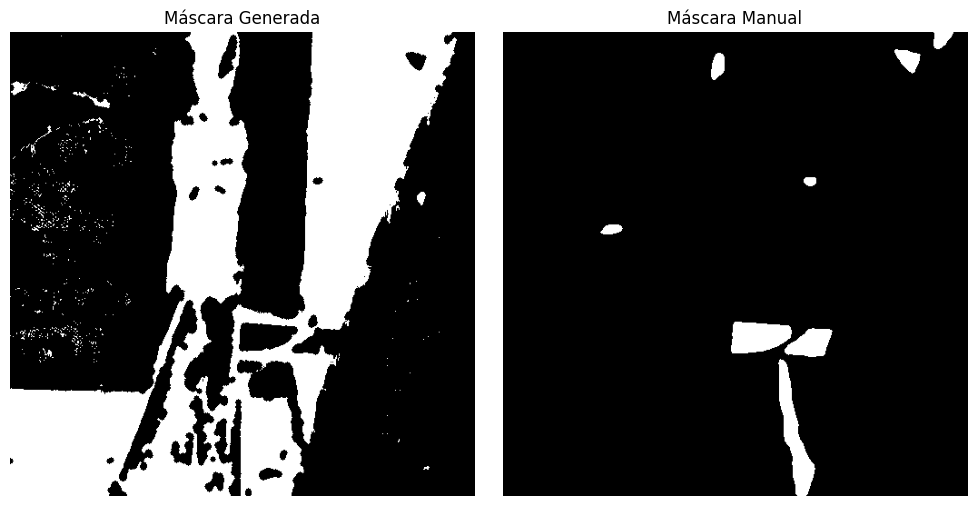

  Intersection over Union (IoU): 0.0132
  Dice Coefficient (F1 Score): 0.0261
  Precision: 0.0140
  Recall (Sensitivity): 0.1876
  Accuracy: 0.6382
  TP: 1272, FP: 89331, FN: 5507, TN: 166034
---------------------------------------------------

--- Evaluando con el conjunto de parámetros: 'Máxima Detección de Color Anómalo 2.0' ---


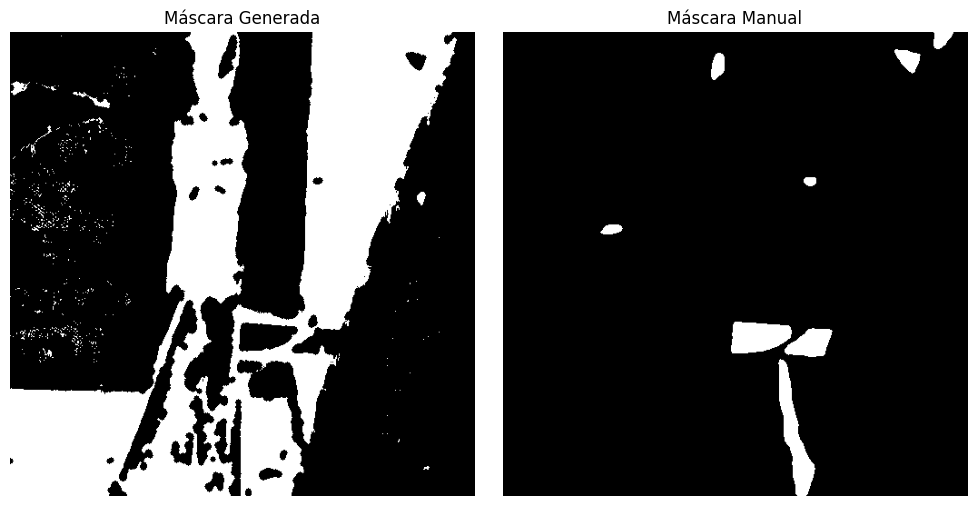

  Intersection over Union (IoU): 0.0132
  Dice Coefficient (F1 Score): 0.0261
  Precision: 0.0140
  Recall (Sensitivity): 0.1876
  Accuracy: 0.6382
  TP: 1272, FP: 89331, FN: 5507, TN: 166034
---------------------------------------------------


--- Visualizando el MEJOR CASO basado en IoU: 'Máxima Detección de Color Anómalo' ---
  Mejor IoU: 0.0132
  Dice Coefficient: 0.0261
  Precision: 0.0140
  Recall: 0.1876
  Accuracy: 0.6382
  TP: 1272, FP: 89331, FN: 5507, TN: 166034


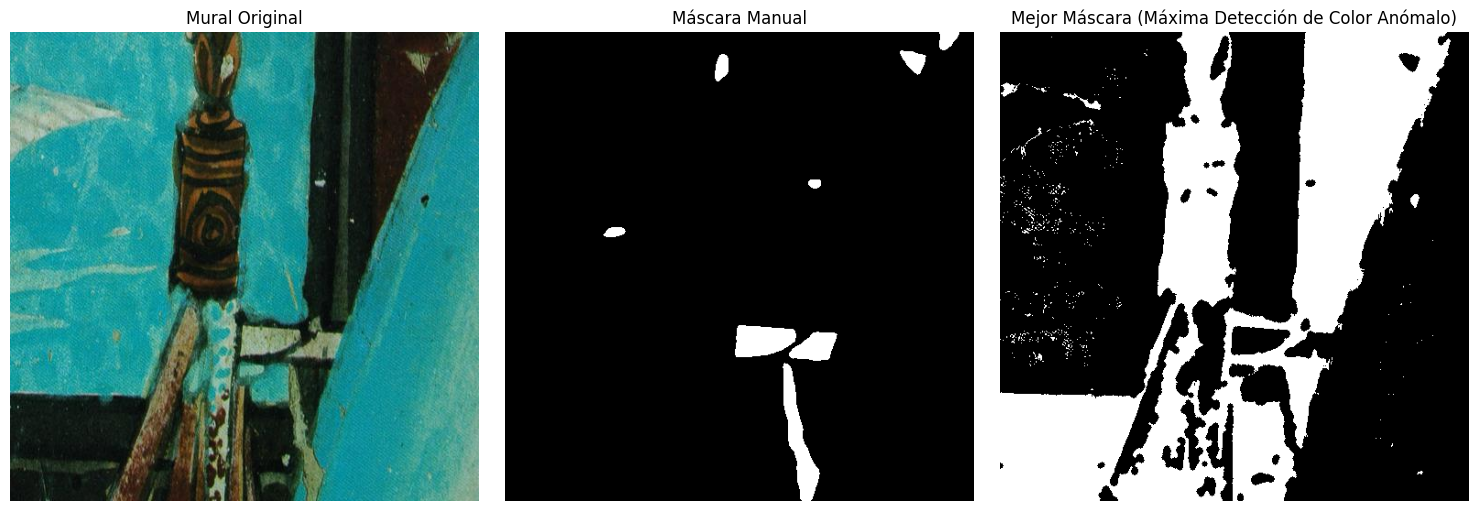

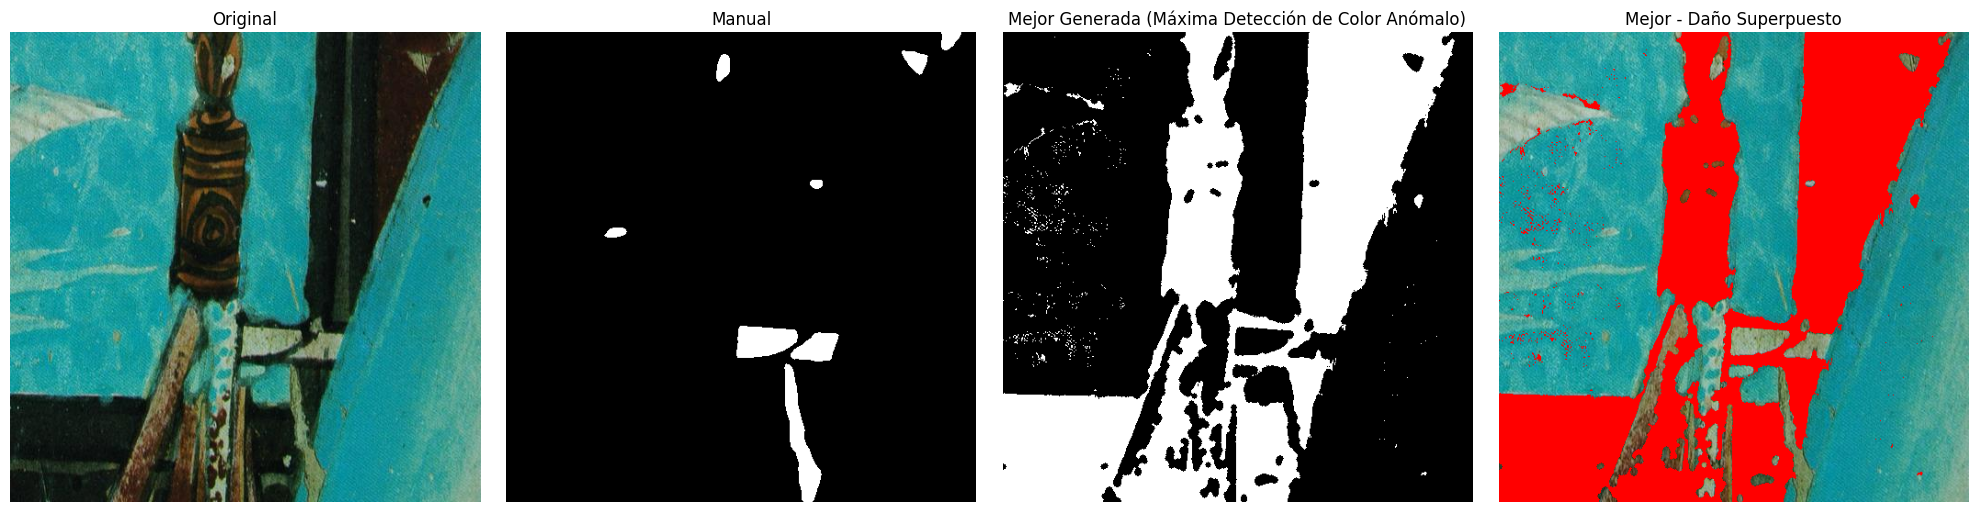

In [41]:
# --- Carga y ejecución ---
img_name = '000055.png'
img_path = f'dataset-&-labels/images/{img_name}'
manual_filter_path = f'dataset-&-labels/labels/{img_name}'

img_original = cv2.imread(img_path)
manual_mask_ground_truth = cv2.imread(manual_filter_path, cv2.IMREAD_GRAYSCALE)

if img_original is None:
    print(f"Error: No se pudo cargar la imagen de {img_path}")
elif manual_mask_ground_truth is None:
    print(f"Error: No se pudo cargar la máscara manual de {manual_filter_path}")
else:
    _, manual_mask_binary = cv2.threshold(manual_mask_ground_truth, 127, 255, cv2.THRESH_BINARY)
    manual_mask_binary = cv2.resize(manual_mask_binary, (img_original.shape[1], img_original.shape[0]))

    print(f"Evaluando la imagen: {img_name}\n")

    best_iou = -1.0
    best_param_set_name = None
    best_final_mask = None
    best_metrics_details = None

    for param_set_with_name in param_sets_to_test:
        current_params = {k: v for k, v in param_set_with_name.items() if k != 'name'}
        params_name = param_set_with_name['name']
        
        print(f"--- Evaluando con el conjunto de parámetros: '{params_name}' ---")
        
        final_damage_mask, _, _, _, _, _, _ = detect_damage_02(
            img_original.copy(),
            **current_params
        )

        show_images([final_damage_mask, manual_mask_binary], 
                    titles=["Máscara Generada", "Máscara Manual"],
                    cmap_list=['gray', 'gray'])
        
        metrics = calculate_metrics(final_damage_mask, manual_mask_binary)
        
        print(f"  Intersection over Union (IoU): {metrics['iou']:.4f}")
        print(f"  Dice Coefficient (F1 Score): {metrics['dice']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall (Sensitivity): {metrics['recall']:.4f}")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        print(f"  TP: {metrics['tp']}, FP: {metrics['fp']}, FN: {metrics['fn']}, TN: {metrics['tn']}")
        print("---------------------------------------------------\n")

        if metrics['iou'] > best_iou:
            best_iou = metrics['iou']
            best_param_set_name = params_name
            best_final_mask = final_damage_mask
            best_metrics_details = metrics # Guardar todas las métricas del mejor caso

    # --- Visualización del MEJOR CASO ---
    if best_final_mask is not None:
        print(f"\n--- Visualizando el MEJOR CASO basado en IoU: '{best_param_set_name}' ---")
        print(f"  Mejor IoU: {best_iou:.4f}")
        if best_metrics_details: # Imprimir todas las métricas del mejor caso
            print(f"  Dice Coefficient: {best_metrics_details['dice']:.4f}")
            print(f"  Precision: {best_metrics_details['precision']:.4f}")
            print(f"  Recall: {best_metrics_details['recall']:.4f}")
            print(f"  Accuracy: {best_metrics_details['accuracy']:.4f}")
            print(f"  TP: {best_metrics_details['tp']}, FP: {best_metrics_details['fp']}, FN: {best_metrics_details['fn']}, TN: {best_metrics_details['tn']}")


        images_to_show_best_case = [
            img_original, manual_mask_binary, best_final_mask
        ]
        titles_to_show_best_case = [
            "Mural Original", "Máscara Manual", f"Mejor Máscara ({best_param_set_name})"
        ]
        cmaps_best_case = [None, 'gray', 'gray']
        show_images(images_to_show_best_case, titles_to_show_best_case, cmaps_best_case)

        overlay_best = img_original.copy()
        overlay_best[best_final_mask == 255] = [0, 0, 255] # Daño en rojo

        # Mostrar original, manual, mejor generada y superposición del mejor caso
        show_images([img_original, manual_mask_binary, best_final_mask, overlay_best],
                    ["Original", "Manual", f"Mejor Generada ({best_param_set_name})", "Mejor - Daño Superpuesto"],
                    [None, 'gray', 'gray', None])
    else:
        print("\nNo se pudo determinar el mejor caso (posiblemente no se probaron conjuntos de parámetros o la máscara manual no está disponible).")